# Generative Adversarial Networks Exploration

Author: Alessio Carnevale

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist

In [2]:
(x_train, y_train), (_, _) = mnist.load_data()
x_train = (x_train / 255.0).astype(np.float32)
x_train = x_train.reshape(-1, 28, 28, 1) # Reshape for input to CNNs

importing y_train for visualization purposes only. It will not be used in the training of the model

In [3]:
x_train.shape

(60000, 28, 28, 1)

### 10 Random images 

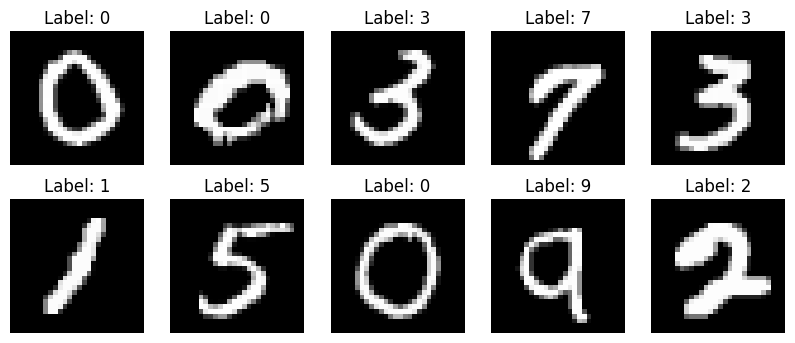

In [4]:
random_indices = np.random.choice(len(x_train), 10, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, idx in enumerate(random_indices):
    axes[i//5, i%5].imshow(x_train[idx].reshape(28, 28), cmap='gray')
    axes[i//5, i%5].set_title(f'Label: {y_train[idx]}')
    axes[i//5, i%5].axis('off')
plt.show()

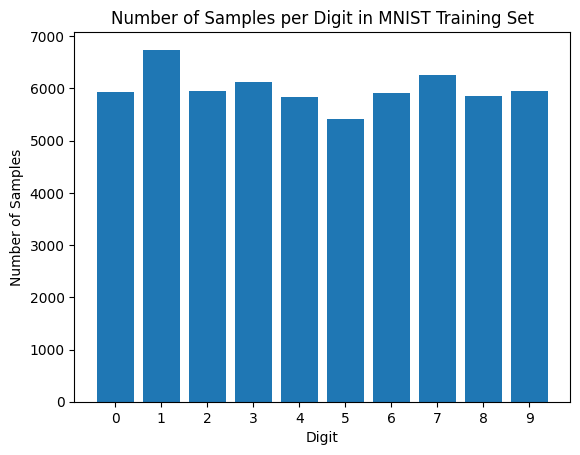

In [5]:
digits, counts = np.unique(y_train, return_counts=True)
plt.bar(digits, counts)
plt.xlabel('Digit')
plt.ylabel('Number of Samples')
plt.title('Number of Samples per Digit in MNIST Training Set')
plt.xticks(digits)
plt.show()

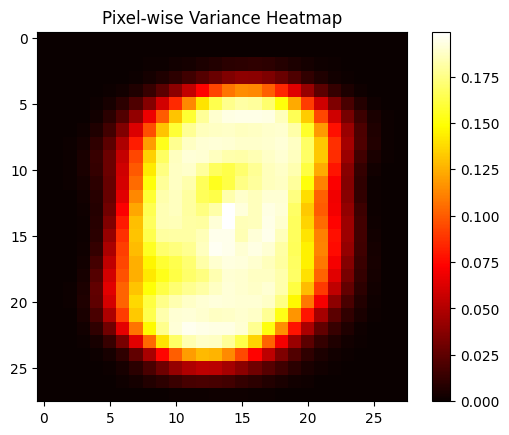

In [6]:
variance = np.var(x_train, axis=0).squeeze()
plt.imshow(variance, cmap='hot')
plt.title('Pixel-wise Variance Heatmap')
plt.colorbar()
plt.show()

## Creating the model

In [7]:
codings_size = 100

generator = keras.models.Sequential([
    keras.layers.Input([codings_size]),
    
    keras.layers.Dense(128),
    keras.layers.LeakyReLU(0.2),
    
    keras.layers.Dense(256),
    keras.layers.LeakyReLU(0.2),
    
    keras.layers.Dense(28 * 28, activation="tanh"),
    keras.layers.Reshape([28, 28, 1])
])



discriminator = keras.models.Sequential([
    keras.layers.Input([28, 28, 1]),
    keras.layers.Flatten(),
    
    keras.layers.Dense(128),
    keras.layers.LeakyReLU(0.2),
    
    keras.layers.Dense(64),
    keras.layers.LeakyReLU(0.2),
    
    keras.layers.Dense(1, activation="sigmoid"),
])

In [8]:
disc_optimizer = keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

gen_optimizer = keras.optimizers.Adam(
    learning_rate=0.0002,
    beta_1=0.5
)

discriminator.compile(
    loss="binary_crossentropy",
    optimizer=disc_optimizer
)

discriminator.trainable = False

gan = keras.models.Sequential([generator, discriminator])

gan.compile(
    loss="binary_crossentropy",
    optimizer=gen_optimizer
)


divide the dataset in batches

In [9]:
batch_size = 64

dataset = tf.data.Dataset.from_tensor_slices(x_train)
dataset = dataset.shuffle(60000)
dataset = dataset.batch(batch_size, drop_remainder=True)

### Train the model

In [10]:
def plot_generated_images(generator, codings_size, n_images=20):
    noise = tf.random.normal([n_images, codings_size])
    generated_images = generator(noise, training=False)

    plt.figure(figsize=(10, 5))
    for i in range(n_images):
        plt.subplot(4, 5, i + 1)
        plt.imshow(generated_images[i, :, :, 0], cmap="gray")
        plt.axis("off")
    plt.show()


In [11]:
def add_instance_noise(images, stddev):
    if stddev > 0:
        return images + tf.random.normal(tf.shape(images), 0.0, stddev)
    return images



def train_gan(gan, dataset, batch_size, codings_size, n_epochs=50):
    generator, discriminator = gan.layers

    for epoch in range(n_epochs):
        print(f"Epoch {epoch+1}/{n_epochs}")

        noise_std = max(0.05 * (1 - epoch / n_epochs), 0.0)


        for x_batch in dataset:
            # -------------------------
            # Phase 1: Train discriminator
            # -------------------------
            discriminator.trainable = True

            noise = tf.random.normal([batch_size, codings_size])
            fake_images = generator(noise, training=True)

            X = tf.concat([
                add_instance_noise(fake_images, noise_std),
                add_instance_noise(x_batch, noise_std)
            ], axis=0)

            y = tf.concat([
                tf.zeros((batch_size, 1)) + tf.random.uniform((batch_size, 1), 0.0, 0.1),
                tf.ones((batch_size, 1)) * 0.9
            ], axis=0)


            discriminator.train_on_batch(X, y)

            # -------------------------
            # Phase 2: Train generator
            # -------------------------
            discriminator.trainable = False

            for _ in range(2):  # <-- THIS IS THE KEY CHANGE


                noise = tf.random.normal([batch_size, codings_size])
                y_gen = tf.ones((batch_size, 1))  # generator wants "real"

                gan.train_on_batch(noise, y_gen)

        # plot_generated_images(generator, codings_size)


x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5
x_train = np.expand_dims(x_train, axis=-1)


train_gan(gan, dataset, batch_size, codings_size)


Epoch 1/50


2025-12-22 10:13:42.861653: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 2/50


2025-12-22 10:13:48.859835: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 3/50
Epoch 4/50


...

Epoch 9/50
Epoch 10/50
Epoch 11/50
Epoch 12/50
Epoch 13/50
Epoch 14/50
Epoch 15/50
Epoch 16/50


2025-12-22 10:15:14.077646: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 17/50
Epoch 18/50
Epoch 19/50
Epoch 20/50
Epoch 21/50
Epoch 22/50
Epoch 23/50
Epoch 24/50
Epoch 25/50
Epoch 26/50
Epoch 27/50
Epoch 28/50
Epoch 29/50
Epoch 30/50
Epoch 31/50
Epoch 32/50


2025-12-22 10:16:51.941520: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 33/50
Epoch 34/50
Epoch 35/50
Epoch 36/50
Epoch 37/50
Epoch 38/50
Epoch 39/50
Epoch 40/50
Epoch 41/50
Epoch 42/50
Epoch 43/50
Epoch 44/50
Epoch 45/50
Epoch 46/50
Epoch 47/50
Epoch 48/50
Epoch 49/50
Epoch 50/50


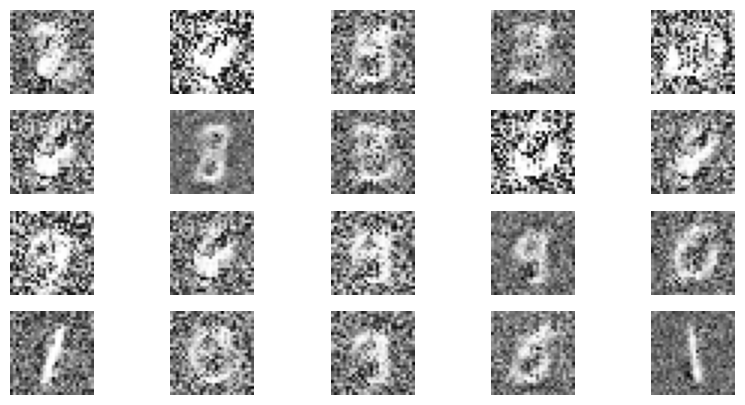

In [12]:
def generate_fake_instances(generator, codings_size, n_samples):
    """
    Generates synthetic (fake) MNIST-like images using a trained generator.

    Returns:
        fake_images: numpy array of shape (n_samples, 28, 28, 1)
    """
    noise = tf.random.normal([n_samples, codings_size])
    fake_images = generator(noise, training=False)
    fake_images = (fake_images + 1) / 2.0

    return fake_images.numpy()

n_fake = 1000
fake_mnist = generate_fake_instances(generator, codings_size, n_fake)

def plot_fake_instances(fake_images, n=20):
    plt.figure(figsize=(10, 5))
    for i in range(n):
        plt.subplot(4, 5, i + 1)
        plt.imshow(fake_images[i, :, :, 0], cmap="gray")
        plt.axis("off")
    plt.show()


plot_fake_instances(fake_mnist)


## Conditional GAN